# CSE 428 Project - Part 2: calibration, error analysis and artefacts

The training notebook completed all eight runs and saved every checkpoint, then raised a
`TypeError` while formatting one line of the threshold-calibration cell. The cause was a duplicate
index: the validation sweep selected 0.5 as the best threshold, so `[0.5, best_thr]` became
`[0.5, 0.5]`, and `.loc[0.5]` then returned a two-row Series where a scalar was expected.

Nothing about the models was affected. This notebook loads those checkpoints and completes the
sections that did not get to run:

- threshold calibration (with the duplicate-index bug fixed)
- confusion matrix and per-class breed analysis
- failure cases
- checkpoint selection comparison
- external-image inference
- `config.json` for the demo notebook

# 1. Configuration and imports

These values must match the training notebook exactly. If `IMG_SIZE` or `BASE_CH` differed, the
saved weights would not fit the reconstructed model and `load_state_dict` would raise - which is
the intended behaviour, since a silent partial load would be far worse.

In [1]:
IMG_SIZE    = 224
BASE_CH     = 64
BATCH_SIZE  = 16
SEED        = 42
NUM_WORKERS = 2
USE_AMP     = True
BACKBONES   = ["mobilenet_v3_large", "efficientnet_b0", "densenet121"]
OUT_DIR     = "/kaggle/working"

import os, glob, json, random, time, math, warnings, subprocess, tarfile
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms.functional as TF
from torchvision import models as tvm
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=UserWarning)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = USE_AMP and device == "cuda"
try:
    from torch.amp import autocast as _autocast, GradScaler as _GradScaler
    _GradScaler("cuda", enabled=False)
    def amp_ctx(en): return _autocast("cuda", enabled=en)
except (ImportError, TypeError):
    from torch.cuda.amp import autocast as _autocast
    def amp_ctx(en): return _autocast(enabled=en)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

ckpts = glob.glob("/kaggle/input/**/base_unet_bestloss.pth", recursive=True)
assert ckpts, ("checkpoints not found - add the training run as an input:\n"
               "right-hand panel -> Add Input -> Notebook Output -> select '428 training'")
ART_DIR = os.path.dirname(ckpts[0])

print(f"Device     - {device} | AMP - {USE_AMP}")
print(f"Checkpoints- {ART_DIR}")
print(f"Found      - {len(glob.glob(f'{ART_DIR}/*.pth'))} .pth files")

Device     - cuda | AMP - True
Checkpoints- /kaggle/input/notebooks/rafiazarinalisha/428-training
Found      - 16 .pth files


# 2. Data and split

The split is recomputed rather than loaded, because `config.json` was written in a cell after the
crash and does not exist yet. It is reproducible: the file list is sorted, the seed is fixed, and
`train_test_split` is deterministic given both. Section 4 verifies this by checking the reproduced
test metrics against `ablation.csv` - if the split had drifted, those numbers would not match.

In [2]:
BASE = "https://www.robots.ox.ac.uk/~vgg/data/pets/data"

def fetch(name):
    if not os.path.exists(name):
        r = subprocess.run(["wget", "-q", f"{BASE}/{name}"])
        assert r.returncode == 0 and os.path.exists(name), f"download of {name} failed"
    with tarfile.open(name) as t:
        try:    t.extractall("/kaggle/working", filter="data")
        except TypeError: t.extractall("/kaggle/working")
    os.remove(name)

if not (os.path.isdir("/kaggle/working/images") and os.path.isdir("/kaggle/working/annotations")):
    for f in ("images.tar.gz", "annotations.tar.gz"):
        fetch(f)
    print("Downloaded and extracted.")
else:
    print("Already present.")

Downloaded and extracted.


In [3]:

image_paths  = sorted(glob.glob("/kaggle/working/**/images/*.jpg", recursive=True))
trimap_paths = sorted(glob.glob("/kaggle/working/**/trimaps/*.png", recursive=True))
trimap_dir   = os.path.dirname(trimap_paths[0])
assert len(image_paths) < 8000, (
    f"{len(image_paths)} images found - expected ~7390. The list is duplicated; "
    "check that only /kaggle/working is being searched.")

samples = []
for p in image_paths:
    stem = os.path.basename(p)[:-4]
    if stem.startswith("."):
        continue
    tp = os.path.join(trimap_dir, stem + ".png")
    if os.path.exists(tp):
        breed = stem.rsplit("_", 1)[0]
        samples.append({"image": p, "trimap": tp, "breed": breed,
                        "species": "cat" if breed[0].isupper() else "dog"})

breeds       = sorted({s["breed"] for s in samples})
breed_to_idx = {b: i for i, b in enumerate(breeds)}
idx_to_breed = {i: b for b, i in breed_to_idx.items()}
NUM_CLASSES  = len(breeds)
IS_CAT       = torch.tensor([b[0].isupper() for b in breeds], device=device)


def load_binary_mask(trimap_path):
    trimap = np.array(Image.open(trimap_path))
    return np.where((trimap == 1) | (trimap == 3), 1, 0).astype(np.uint8)


class PetDataset(Dataset):
    def __init__(self, samples, breed_to_idx):
        self.samples, self.breed_to_idx = samples, breed_to_idx
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        image = Image.open(s["image"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        mask  = Image.fromarray(load_binary_mask(s["trimap"])).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
        image = TF.normalize(TF.to_tensor(image), IMAGENET_MEAN, IMAGENET_STD)
        mask  = torch.from_numpy(np.array(mask)).float().unsqueeze(0)
        return image, mask, self.breed_to_idx[s["breed"]]


def denorm(t):
    m = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    s = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t.detach().cpu() * s + m).clamp(0, 1).permute(1, 2, 0).numpy()


plain_ds = PetDataset(samples, breed_to_idx)

y   = np.array([breed_to_idx[s["breed"]] for s in samples])
idx = np.arange(len(samples))
tr_idx, tmp_idx   = train_test_split(idx, test_size=0.30, stratify=y, random_state=SEED)
val_idx, test_idx = train_test_split(tmp_idx, test_size=0.50, stratify=y[tmp_idx], random_state=SEED)

def loader(ids, shuffle=False):
    return DataLoader(Subset(plain_ds, list(ids)), batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=(device == "cuda"))

train_loader = loader(tr_idx); val_loader = loader(val_idx); test_loader = loader(test_idx)

print(f"Pairs {len(samples)} | Breeds {NUM_CLASSES}")
print(f"Train {len(tr_idx)} | Val {len(val_idx)} | Test {len(test_idx)}")

Pairs 7390 | Breeds 37
Train 5173 | Val 1108 | Test 1109


# 3. Model definitions

Identical to the training notebook. `load_state_dict` is called with `strict=True` further down, so
any drift in a layer name or shape raises immediately rather than loading a partial model that would
run and quietly produce wrong output.

`pretrained=False` everywhere - the weights come from the checkpoints, so downloading ImageNet
weights would be wasted work.

In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.block(x)


def classifier_head(in_f, n_classes, p=0.3):
    return nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                         nn.Linear(in_f, 256), nn.ReLU(inplace=True),
                         nn.Dropout(p), nn.Linear(256, n_classes))


class MultiTaskUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, n_classes=NUM_CLASSES, c=BASE_CH):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.down1 = DoubleConv(in_ch, c); self.down2 = DoubleConv(c, c*2)
        self.down3 = DoubleConv(c*2, c*4); self.down4 = DoubleConv(c*4, c*8)
        self.bottleneck = DoubleConv(c*8, c*16)
        self.up4 = nn.ConvTranspose2d(c*16, c*8, 2, 2); self.conv4 = DoubleConv(c*16, c*8)
        self.up3 = nn.ConvTranspose2d(c*8, c*4, 2, 2);  self.conv3 = DoubleConv(c*8, c*4)
        self.up2 = nn.ConvTranspose2d(c*4, c*2, 2, 2);  self.conv2 = DoubleConv(c*4, c*2)
        self.up1 = nn.ConvTranspose2d(c*2, c, 2, 2);    self.conv1 = DoubleConv(c*2, c)
        self.final = nn.Conv2d(c, out_ch, 1)
        self.classifier = classifier_head(c*16, n_classes)
    def forward(self, x):
        d1 = self.down1(x); d2 = self.down2(self.pool(d1))
        d3 = self.down3(self.pool(d2)); d4 = self.down4(self.pool(d3))
        b  = self.bottleneck(self.pool(d4))
        cls = self.classifier(b)
        u4 = self.conv4(torch.cat([self.up4(b),  d4], 1))
        u3 = self.conv3(torch.cat([self.up3(u4), d3], 1))
        u2 = self.conv2(torch.cat([self.up2(u3), d2], 1))
        u1 = self.conv1(torch.cat([self.up1(u2), d1], 1))
        return self.final(u1), cls


class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        alpha = self.psi(self.relu(self.W_g(g) + self.W_x(x)))
        return x * alpha, alpha


class MultiTaskAttentionUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, n_classes=NUM_CLASSES, c=BASE_CH):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.down1 = DoubleConv(in_ch, c); self.down2 = DoubleConv(c, c*2)
        self.down3 = DoubleConv(c*2, c*4); self.down4 = DoubleConv(c*4, c*8)
        self.bottleneck = DoubleConv(c*8, c*16)
        self.up4 = nn.ConvTranspose2d(c*16, c*8, 2, 2)
        self.att4 = AttentionGate(c*8, c*8, c*4); self.conv4 = DoubleConv(c*16, c*8)
        self.up3 = nn.ConvTranspose2d(c*8, c*4, 2, 2)
        self.att3 = AttentionGate(c*4, c*4, c*2); self.conv3 = DoubleConv(c*8, c*4)
        self.up2 = nn.ConvTranspose2d(c*4, c*2, 2, 2)
        self.att2 = AttentionGate(c*2, c*2, c);   self.conv2 = DoubleConv(c*4, c*2)
        self.up1 = nn.ConvTranspose2d(c*2, c, 2, 2)
        self.att1 = AttentionGate(c, c, c//2);    self.conv1 = DoubleConv(c*2, c)
        self.final = nn.Conv2d(c, out_ch, 1)
        self.classifier = classifier_head(c*16, n_classes)
    def forward(self, x, return_attn=False):
        d1 = self.down1(x); d2 = self.down2(self.pool(d1))
        d3 = self.down3(self.pool(d2)); d4 = self.down4(self.pool(d3))
        b  = self.bottleneck(self.pool(d4))
        cls = self.classifier(b)
        g4 = self.up4(b);  a4, w4 = self.att4(g4, d4); u4 = self.conv4(torch.cat([a4, g4], 1))
        g3 = self.up3(u4); a3, w3 = self.att3(g3, d3); u3 = self.conv3(torch.cat([a3, g3], 1))
        g2 = self.up2(u3); a2, w2 = self.att2(g2, d2); u2 = self.conv2(torch.cat([a2, g2], 1))
        g1 = self.up1(u2); a1, w1 = self.att1(g1, d1); u1 = self.conv1(torch.cat([a1, g1], 1))
        seg = self.final(u1)
        if return_attn: return seg, cls, [w1, w2, w3, w4]
        return seg, cls


def _stages(name, pretrained):
    w = "IMAGENET1K_V1" if pretrained else None
    if name == "resnet34":
        m = tvm.resnet34(weights=w)
        return [nn.Sequential(m.conv1, m.bn1, m.relu),
                nn.Sequential(m.maxpool, m.layer1), m.layer2, m.layer3, m.layer4]
    if name == "mobilenet_v3_large":
        f = tvm.mobilenet_v3_large(weights=w).features
        return [f[0:2], f[2:4], f[4:7], f[7:13], f[13:]]
    if name == "efficientnet_b0":
        f = tvm.efficientnet_b0(weights=w).features
        return [f[0:2], f[2:3], f[3:4], f[4:6], f[6:]]
    if name == "densenet121":
        f = tvm.densenet121(weights=w).features
        return [f[0:3], f[3:5], f[5:7], f[7:9], f[9:]]
    raise ValueError(name)


class BackboneUNet(nn.Module):
    def __init__(self, backbone="resnet34", out_ch=1, n_classes=NUM_CLASSES, pretrained=False):
        super().__init__()
        self.backbone_name = backbone
        self.stages = nn.ModuleList(_stages(backbone, pretrained))
        with torch.no_grad():
            x = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            ch, sz = [], []
            for s in self.stages:
                x = s(x); ch.append(x.shape[1]); sz.append(x.shape[-1])
        assert sz == [IMG_SIZE // k for k in (2, 4, 8, 16, 32)], f"{backbone}: {sz}"
        self.enc_ch = ch
        c0, c1, c2, c3, c4 = ch
        d3, d2, d1, d0 = 256, 128, 64, 48
        self.up4 = nn.ConvTranspose2d(c4, d3, 2, 2); self.dec4 = DoubleConv(d3 + c3, d3)
        self.up3 = nn.ConvTranspose2d(d3, d2, 2, 2); self.dec3 = DoubleConv(d2 + c2, d2)
        self.up2 = nn.ConvTranspose2d(d2, d1, 2, 2); self.dec2 = DoubleConv(d1 + c1, d1)
        self.up1 = nn.ConvTranspose2d(d1, d0, 2, 2); self.dec1 = DoubleConv(d0 + c0, d0)
        self.up0 = nn.ConvTranspose2d(d0, 32, 2, 2); self.dec0 = DoubleConv(32, 32)
        self.final = nn.Conv2d(32, out_ch, 1)
        self.classifier = classifier_head(c4, n_classes)
    def forward(self, x):
        e0 = self.stages[0](x); e1 = self.stages[1](e0); e2 = self.stages[2](e1)
        e3 = self.stages[3](e2); e4 = self.stages[4](e3)
        cls = self.classifier(e4)
        u4 = self.dec4(torch.cat([self.up4(e4), e3], 1))
        u3 = self.dec3(torch.cat([self.up3(u4), e2], 1))
        u2 = self.dec2(torch.cat([self.up2(u3), e1], 1))
        u1 = self.dec1(torch.cat([self.up1(u2), e0], 1))
        return self.final(self.dec0(self.up0(u1))), cls


MODELS = {
    "1. Base U-Net":              ("base_unet",         lambda: MultiTaskUNet()),
    "2. Attention U-Net":         ("attn_unet",         lambda: MultiTaskAttentionUNet()),
    "3. Attention U-Net + aug":   ("attn_unet_aug",     lambda: MultiTaskAttentionUNet()),
    "4. ResNet34 random + aug":   ("resnet_scratch",    lambda: BackboneUNet("resnet34")),
    "5. ResNet34 ImageNet + aug": ("resnet_pretrained", lambda: BackboneUNet("resnet34")),
}
for i, bb in enumerate(BACKBONES):
    MODELS[f"{6+i}. {bb} ImageNet + aug"] = (f"bb_{bb}", lambda b=bb: BackboneUNet(b))

for k, (ck, _) in MODELS.items():
    print(f"  {'[found]' if os.path.exists(f'{ART_DIR}/{ck}_bestloss.pth') else '[MISSING]'} {k}")

  [found] 1. Base U-Net
  [found] 2. Attention U-Net
  [found] 3. Attention U-Net + aug
  [found] 4. ResNet34 random + aug
  [found] 5. ResNet34 ImageNet + aug
  [found] 6. mobilenet_v3_large ImageNet + aug
  [found] 7. efficientnet_b0 ImageNet + aug
  [found] 8. densenet121 ImageNet + aug


# 4. Metrics and loading the best model

The best run is selected on **validation** breed accuracy, exactly as the training notebook did.
That number is read from each run's saved history CSV rather than recomputed, so the selection is
the one the original run would have made.

In [5]:
METRIC_COLS = ["Pixel Acc", "Pet IoU", "mIoU", "Pet Dice", "mDice",
               "Cls Acc", "Top-5 Acc", "Species Acc", "Precision", "Recall", "F1"]

@torch.no_grad()
def run_eval(model, loader, thr=0.5):
    model.eval()
    inter, union = np.zeros(2), np.zeros(2)
    pred_px, true_px = np.zeros(2), np.zeros(2)
    correct_px = total_px = top5 = sp = n = 0
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    for images, masks, labels in loader:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True).float()
        labels = labels.to(device, non_blocking=True).long()
        with amp_ctx(USE_AMP):
            seg_logits, cls_logits = model(images)

        seg_pred = (torch.sigmoid(seg_logits.float()) > thr).long().squeeze(1)
        seg_true = masks.long().squeeze(1)
        correct_px += (seg_pred == seg_true).sum().item(); total_px += seg_true.numel()
        for c in (0, 1):
            p, t = (seg_pred == c), (seg_true == c)
            inter[c] += (p & t).sum().item(); union[c] += (p | t).sum().item()
            pred_px[c] += p.sum().item();     true_px[c] += t.sum().item()

        cl = cls_logits.float(); n += images.size(0)
        k = min(5, cl.size(1))
        top5 += (cl.topk(k, 1).indices == labels.unsqueeze(1)).any(1).sum().item()
        pred = cl.argmax(1)
        sp += (IS_CAT[pred] == IS_CAT[labels]).sum().item()
        cm += np.bincount(labels.cpu().numpy()*NUM_CLASSES + pred.cpu().numpy(),
                          minlength=NUM_CLASSES**2).reshape(NUM_CLASSES, NUM_CLASSES)

    iou  = inter / np.maximum(union, 1e-9)
    dice = 2*inter / np.maximum(pred_px + true_px, 1e-9)
    tp   = np.diag(cm).astype(np.float64)
    prec = tp / np.maximum(cm.sum(0), 1e-9)
    rec  = tp / np.maximum(cm.sum(1), 1e-9)
    f1   = 2*prec*rec / np.maximum(prec + rec, 1e-9)
    seen = cm.sum(1) > 0
    return {"Pixel Acc": correct_px/total_px, "Pet IoU": iou[1], "mIoU": iou.mean(),
            "Pet Dice": dice[1], "mDice": dice.mean(),
            "Cls Acc": tp.sum()/cm.sum(), "Top-5 Acc": top5/n, "Species Acc": sp/n,
            "Precision": prec[seen].mean(), "Recall": rec[seen].mean(), "F1": f1[seen].mean()}, cm


def load_run(name, which="bestloss"):
    ck, ctor = MODELS[name]
    m = ctor().to(device)
    m.load_state_dict(torch.load(f"{ART_DIR}/{ck}_{which}.pth", map_location=device), strict=True)
    m.eval()
    return m

best_val = {}
for nm, (ck, _) in MODELS.items():
    h = f"{ART_DIR}/{ck}_history.csv"
    if os.path.exists(h):
        best_val[nm] = pd.read_csv(h)["val_Cls Acc"].max()

print("Best validation breed accuracy per run\n")
for nm, v in sorted(best_val.items(), key=lambda kv: -kv[1]):
    print(f"  {nm:<36} {v:.4f}")

BEST_NAME = max(best_val, key=best_val.get)
BEST_CKPT = MODELS[BEST_NAME][0]
model = load_run(BEST_NAME)
print(f"\nSelected on validation - {BEST_NAME}")
print(f"Checkpoint - {BEST_CKPT}_bestloss.pth")
print(f"Params     - {sum(p.numel() for p in model.parameters()):,}")

Best validation breed accuracy per run

  7. efficientnet_b0 ImageNet + aug    0.9440
  8. densenet121 ImageNet + aug        0.9350
  5. ResNet34 ImageNet + aug           0.9251
  6. mobilenet_v3_large ImageNet + aug 0.9125
  1. Base U-Net                        0.4305
  4. ResNet34 random + aug             0.3646
  2. Attention U-Net                   0.1661
  3. Attention U-Net + aug             0.0686

Selected on validation - 7. efficientnet_b0 ImageNet + aug
Checkpoint - bb_efficientnet_b0_bestloss.pth
Params     - 7,773,714


## Verifying the split was reconstructed correctly

The split here was recomputed, not loaded. If it had drifted - a different file ordering, a
different seed - the test set would contain different images and the metrics would not match those
already reported in `ablation.csv`. This cell checks them.

In [6]:
best_res, best_cm = run_eval(model, test_loader, thr=0.5)
abl = pd.read_csv(f"{ART_DIR}/ablation.csv", index_col=0)

row = abl.loc[BEST_NAME] if BEST_NAME in abl.index else None
if row is not None:
    comp = pd.DataFrame({"reported (training run)": row[METRIC_COLS].astype(float),
                         "reproduced here": pd.Series(best_res)[METRIC_COLS]})
    comp["diff"] = comp["reproduced here"] - comp["reported (training run)"]
    print(comp.round(4).to_string())
    worst = comp["diff"].abs().max()
    print(f"\n{'MATCH' if worst < 0.005 else 'MISMATCH'} - largest difference {worst:.5f}")
    if worst < 0.005:
        print("The split, breed ordering and weights all reconstructed correctly.")
    else:
        print("Investigate: the reconstructed split may differ from the training run's.")
else:
    print(f"{BEST_NAME} not found in ablation.csv; skipping the cross-check.")
    print(pd.Series(best_res).round(4).to_string())

             reported (training run)  reproduced here  diff
Pixel Acc                     0.9670           0.9670   0.0
Pet IoU                       0.9239           0.9239  -0.0
mIoU                          0.9344           0.9344   0.0
Pet Dice                      0.9604           0.9604   0.0
mDice                         0.9661           0.9661  -0.0
Cls Acc                       0.9243           0.9243  -0.0
Top-5 Acc                     0.9901           0.9901  -0.0
Species Acc                   0.9964           0.9964  -0.0
Precision                     0.9279           0.9279  -0.0
Recall                        0.9240           0.9240   0.0
F1                            0.9227           0.9227   0.0

MATCH - largest difference 0.00004
The split, breed ordering and weights all reconstructed correctly.


# 5. Threshold calibration

Every segmentation number so far uses a 0.5 cut on the sigmoid, which is a default rather than a
choice. The sweep runs on the **validation** set and the winner is applied once to the test set -
picking a threshold on test and reporting on test would be fitting to the test set.

**The bug that stopped the training notebook, and the fix.** The original built the test sweep as
`[0.5, best_thr]`. Validation selected 0.5, so the list became `[0.5, 0.5]`, and the resulting
DataFrame had a duplicate index. `.loc[0.5]` then returned a two-row Series rather than a scalar,
and the f-string could not format it.

`sorted({0.5, best_thr})` builds a set first, which deduplicates. When the calibrated threshold is
already 0.5 the sweep has one row and the reported change is zero, which is correct.

Validation sweep

           Pet IoU    mIoU
threshold                 
0.30        0.9197  0.9298
0.35        0.9208  0.9310
0.40        0.9215  0.9317
0.45        0.9218  0.9321
0.50        0.9219  0.9323
0.55        0.9217  0.9323
0.60        0.9212  0.9320
0.65        0.9203  0.9313
0.70        0.9189  0.9303

Best validation threshold - 0.5

Applied to test

           Pet IoU    mIoU
threshold                 
0.5         0.9239  0.9344

Pet IoU change from recalibrating 0.5 -> 0.5: +0.0000
The default 0.5 was already optimal on validation, so nothing changes.
That is a result: the model's probabilities are well calibrated for this task.


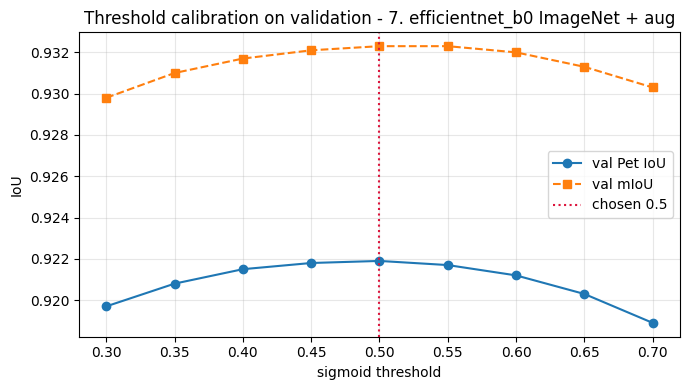

In [7]:
@torch.no_grad()
def threshold_sweep(model, loader, thresholds):
    model.eval()
    inter = {t: np.zeros(2) for t in thresholds}
    union = {t: np.zeros(2) for t in thresholds}
    for im, mk, _ in loader:
        with amp_ctx(USE_AMP):
            probs = torch.sigmoid(model(im.to(device))[0].float()).squeeze(1)
        true = mk.to(device).long().squeeze(1)
        for t in thresholds:
            pred = (probs > t).long()
            for c in (0, 1):
                p, q = (pred == c), (true == c)
                inter[t][c] += (p & q).sum().item()
                union[t][c] += (p | q).sum().item()
    return pd.DataFrame([{"threshold": t,
                          "Pet IoU": (inter[t]/np.maximum(union[t], 1e-9))[1],
                          "mIoU":    (inter[t]/np.maximum(union[t], 1e-9)).mean()}
                         for t in thresholds]).set_index("threshold").round(4)

THRESHOLDS = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
sweep_val = threshold_sweep(model, val_loader, THRESHOLDS)
best_thr  = float(sweep_val["Pet IoU"].idxmax())
print("Validation sweep\n"); print(sweep_val.to_string())
print(f"\nBest validation threshold - {best_thr}")

# sorted(set(...)) collapses the duplicate when best_thr is itself 0.5
sweep_test = threshold_sweep(model, test_loader, sorted({0.5, best_thr}))
print("\nApplied to test\n"); print(sweep_test.to_string())

gain = float(sweep_test.loc[best_thr, "Pet IoU"]) - float(sweep_test.loc[0.5, "Pet IoU"])
print(f"\nPet IoU change from recalibrating 0.5 -> {best_thr}: {gain:+.4f}")
if abs(best_thr - 0.5) < 1e-9:
    print("The default 0.5 was already optimal on validation, so nothing changes.")
    print("That is a result: the model's probabilities are well calibrated for this task.")

fig = plt.figure(figsize=(7, 4))
plt.plot(sweep_val.index, sweep_val["Pet IoU"], "o-", label="val Pet IoU")
plt.plot(sweep_val.index, sweep_val["mIoU"], "s--", label="val mIoU")
plt.axvline(best_thr, ls=":", c="crimson", label=f"chosen {best_thr}")
plt.xlabel("sigmoid threshold"); plt.ylabel("IoU"); plt.legend(); plt.grid(alpha=0.3)
plt.title(f"Threshold calibration on validation - {BEST_NAME}")
plt.tight_layout(); plt.show(); plt.close(fig)

# 6. Error analysis

## Confusion matrix

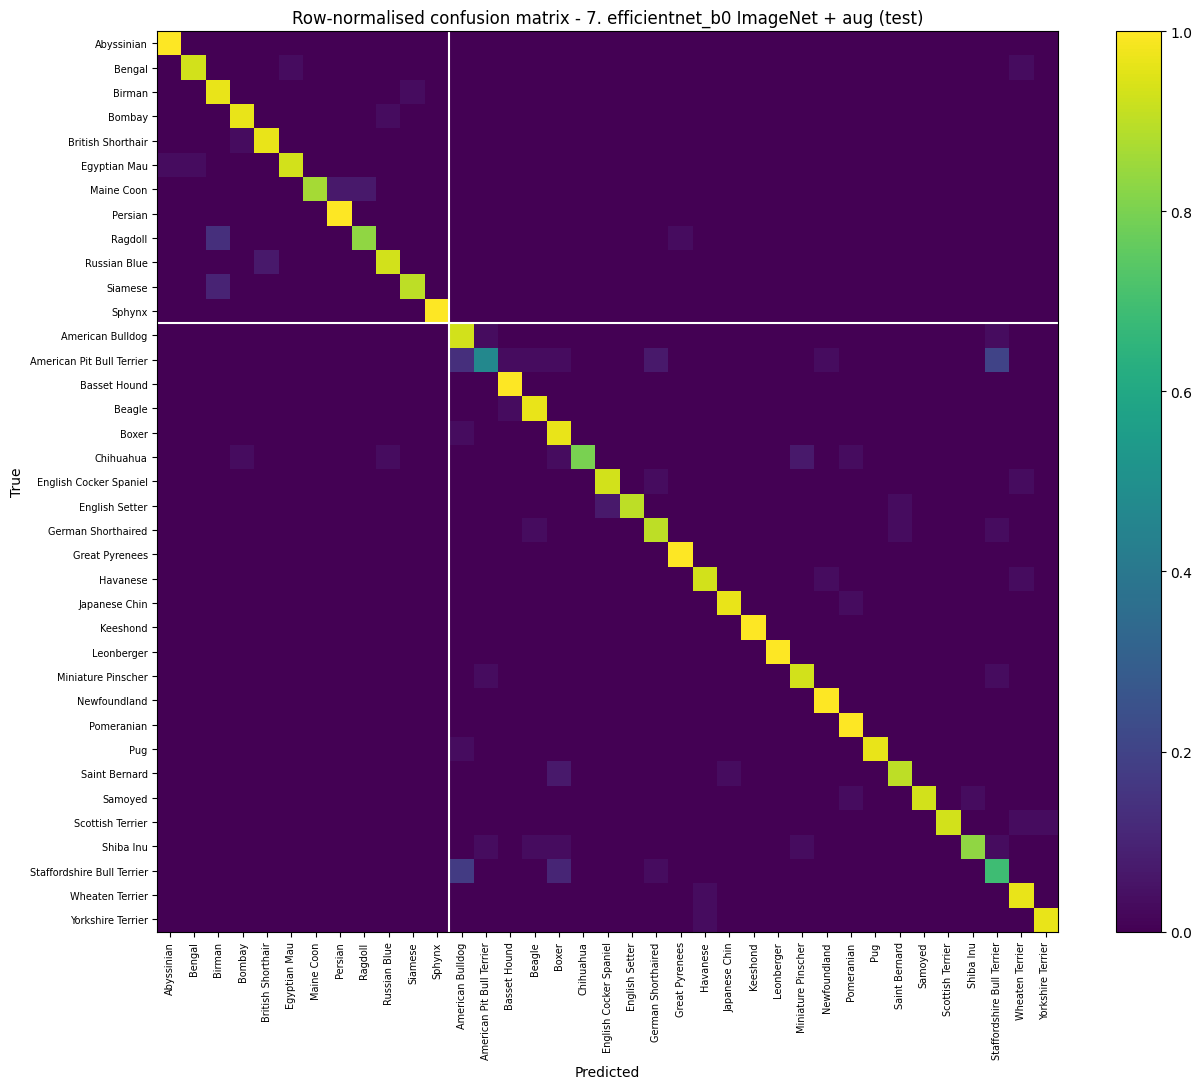

White lines separate the 12 cat breeds (top-left) from the 25 dogs.
Mass inside a diagonal block is a confusion between similar breeds; mass in an
off-diagonal block is a cat/dog error, which is a much cruder mistake.


In [8]:
cm_norm = best_cm / np.maximum(best_cm.sum(1, keepdims=True), 1)

def pretty(b):  return b.replace("_", " ").title()
def species(b): return "cat" if b[0].isupper() else "dog"

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(cm_norm, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels([pretty(b) for b in breeds], rotation=90, fontsize=7)
ax.set_yticklabels([pretty(b) for b in breeds], fontsize=7)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Row-normalised confusion matrix - {BEST_NAME} (test)")
n_cats = int(IS_CAT.sum().item())
ax.axhline(n_cats - 0.5, color="w", lw=1.5); ax.axvline(n_cats - 0.5, color="w", lw=1.5)
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show(); plt.close(fig)

print(f"White lines separate the {n_cats} cat breeds (top-left) from the {NUM_CLASSES-n_cats} dogs.")
print("Mass inside a diagonal block is a confusion between similar breeds; mass in an")
print("off-diagonal block is a cat/dog error, which is a much cruder mistake.")

## Per-class accuracy

Five hardest breeds

                     breed species  support  accuracy
 American Pit Bull Terrier     dog       30     0.467
Staffordshire Bull Terrier     dog       29     0.690
                 Chihuahua     dog       30     0.800
                   Ragdoll     cat       30     0.833
                 Shiba Inu     dog       30     0.833

Five easiest breeds

         breed species  support  accuracy
Great Pyrenees     dog       30       1.0
  Newfoundland     dog       30       1.0
    Leonberger     dog       30       1.0
      Keeshond     dog       30       1.0
    Pomeranian     dog       30       1.0

Cat breeds mean accuracy - 0.942
Dog breeds mean accuracy - 0.916

Most frequent single confusions (true -> predicted)

  American Pit Bull Terrier      -> Staffordshire Bull Terrier       6  (same species)
  Staffordshire Bull Terrier     -> American Bulldog                 5  (same species)
  American Pit Bull Terrier      -> American Bulldog                 4  (same species)

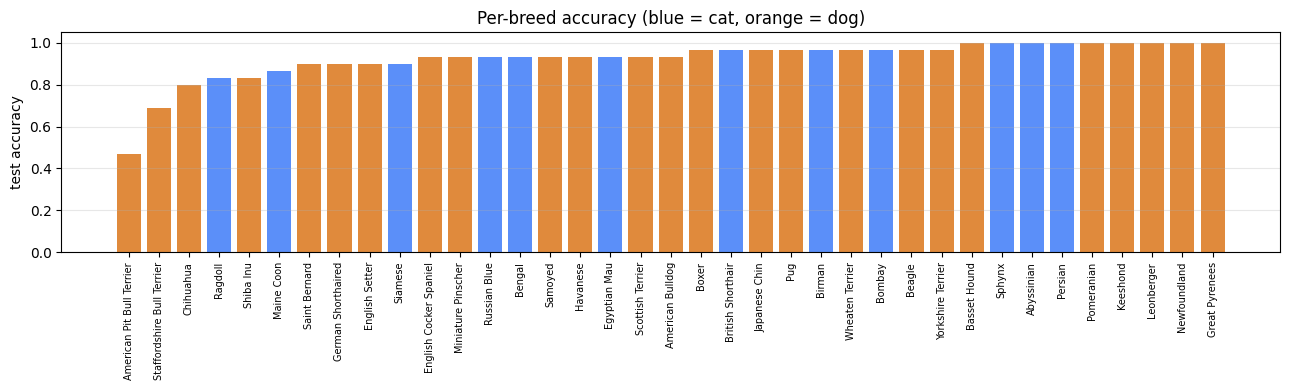

In [9]:
per_cls = np.diag(best_cm) / np.maximum(best_cm.sum(1), 1)
tbl = pd.DataFrame({"breed": [pretty(b) for b in breeds],
                    "species": ["cat" if c else "dog" for c in IS_CAT.cpu().numpy()],
                    "support": best_cm.sum(1), "accuracy": per_cls.round(3)}).sort_values("accuracy")

print("Five hardest breeds\n"); print(tbl.head(5).to_string(index=False))
print("\nFive easiest breeds\n"); print(tbl.tail(5).iloc[::-1].to_string(index=False))
print(f"\nCat breeds mean accuracy - {tbl[tbl.species=='cat'].accuracy.mean():.3f}")
print(f"Dog breeds mean accuracy - {tbl[tbl.species=='dog'].accuracy.mean():.3f}")

print("\nMost frequent single confusions (true -> predicted)\n")
off = best_cm.copy(); np.fill_diagonal(off, 0)
for a, b in zip(*np.unravel_index(np.argsort(off, axis=None)[::-1][:8], off.shape)):
    if off[a, b] == 0: break
    same = "same species" if IS_CAT[a] == IS_CAT[b] else "CROSS-SPECIES"
    print(f"  {pretty(breeds[a]):<30} -> {pretty(breeds[b]):<30} {off[a,b]:>3}  ({same})")

fig = plt.figure(figsize=(13, 4))
o = np.argsort(per_cls)
plt.bar(range(NUM_CLASSES), per_cls[o],
        color=["#5b8ff9" if IS_CAT[i] else "#e08a3c" for i in o])
plt.xticks(range(NUM_CLASSES), [pretty(breeds[i]) for i in o], rotation=90, fontsize=7)
plt.ylabel("test accuracy"); plt.title("Per-breed accuracy (blue = cat, orange = dog)")
plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show(); plt.close(fig)

## Prediction display

The format: original class, predicted class, IoU, and three
panels showing the image, the true mask overlay and the predicted mask overlay.

IoU here is per-image - intersection over union of the predicted and true foreground for that single
picture - which is not the same as the dataset-level Pet IoU in the tables above. A single image can
score well below the aggregate and nothing is wrong.

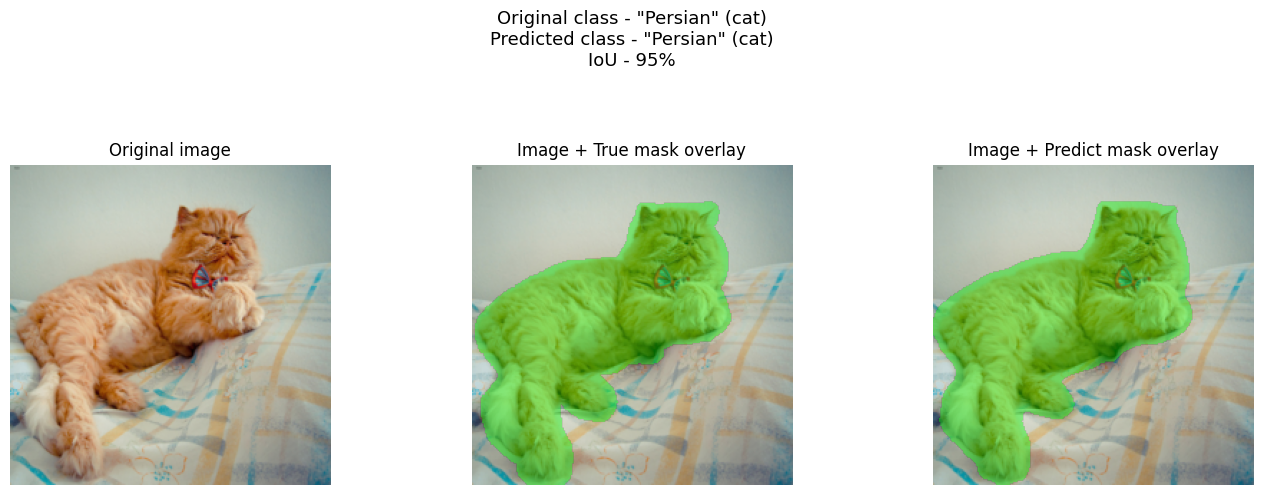

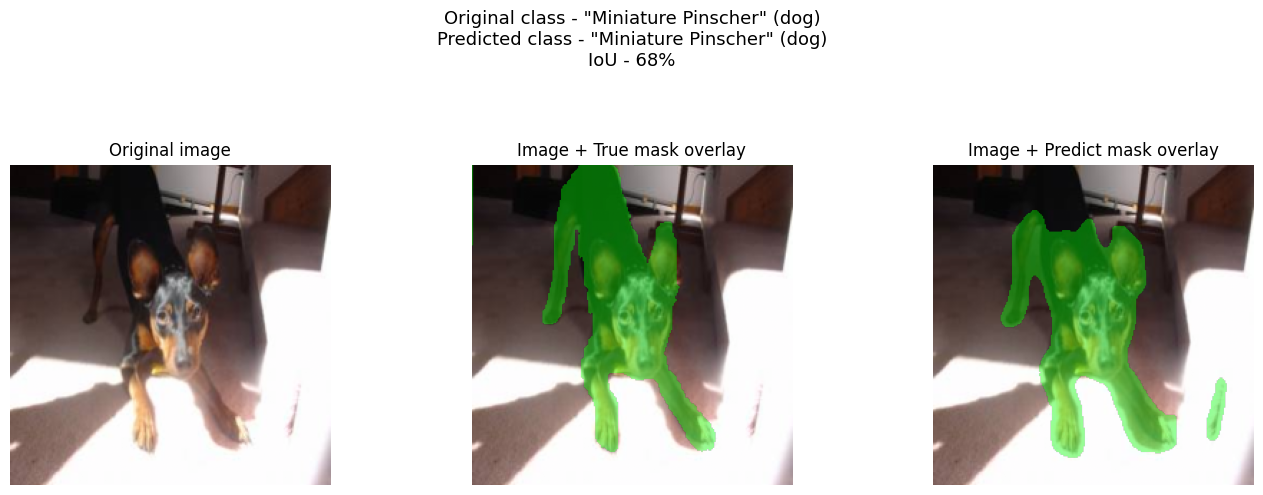

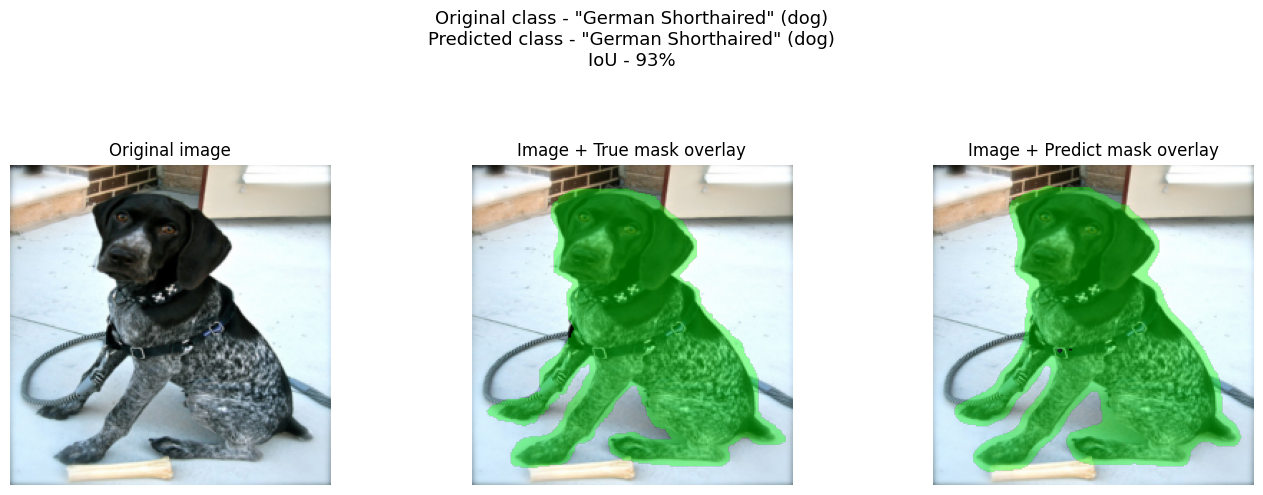

In [10]:
def overlay(mask, rgb=(0.0, 1.0, 0.0)):
    o = np.zeros((*mask.shape, 4)); o[mask == 1] = [*rgb, 0.4]
    return o

@torch.no_grad()
def show_prediction(model, dataset, idx, thr=None):
    thr = best_thr if thr is None else thr
    model.eval()
    image, mask, label = dataset[idx]
    seg_logits, cls_logits = model(image.unsqueeze(0).to(device))
    pred_mask  = (torch.sigmoid(seg_logits.float()) > thr).long().squeeze().cpu().numpy()
    pred_label = cls_logits.float().argmax(1).item()
    true_mask = mask.squeeze().numpy(); img_np = denorm(image)

    i = np.logical_and(pred_mask == 1, true_mask == 1).sum()
    u = np.logical_or(pred_mask == 1, true_mask == 1).sum()
    iou = i / u if u > 0 else 0.0
    tb, pb = idx_to_breed[label], idx_to_breed[pred_label]

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.suptitle(f'Original class - "{pretty(tb)}" ({species(tb)})\n'
                 f'Predicted class - "{pretty(pb)}" ({species(pb)})\n'
                 f'IoU - {iou*100:.0f}%', fontsize=13)
    axes[0].imshow(img_np); axes[0].set_title("Original image")
    axes[1].imshow(img_np); axes[1].imshow(overlay(true_mask))
    axes[1].set_title("Image + True mask overlay")
    axes[2].imshow(img_np); axes[2].imshow(overlay(pred_mask))
    axes[2].set_title("Image + Predict mask overlay")
    for a in axes: a.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.85]); plt.show(); plt.close(fig)
    return iou, tb == pb

test_sub = Subset(plain_ds, list(test_idx))
for i in random.Random(SEED).sample(range(len(test_idx)), 3):
    show_prediction(model, test_sub, i)

## Failure cases

Random samples show what the model usually does; failures show where it breaks. Two kinds: the
lowest-IoU segmentations, and the classifications that were both wrong and confident.

--- 3 worst segmentations by Pet IoU ---


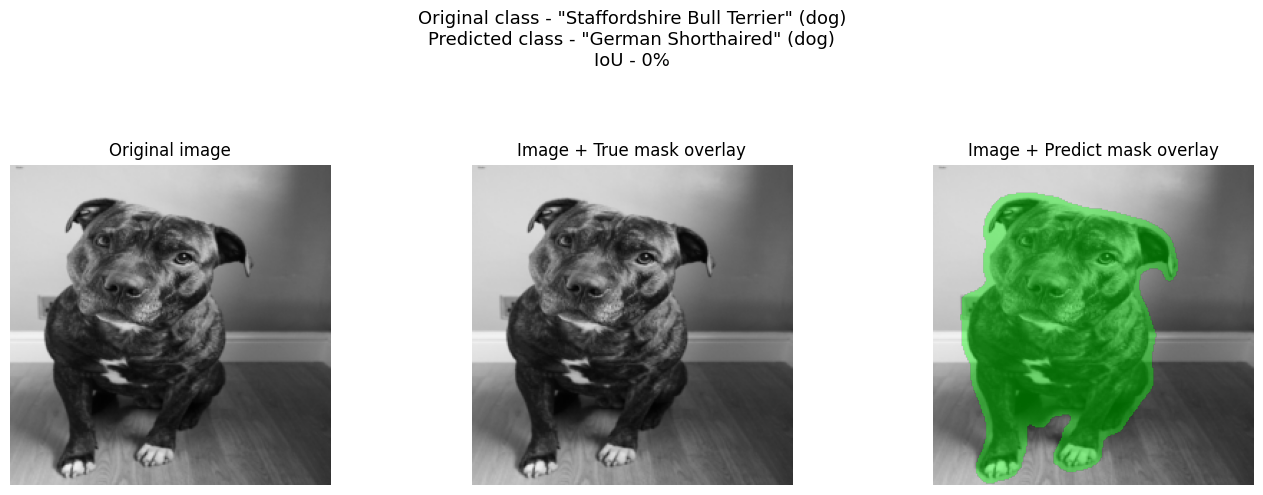

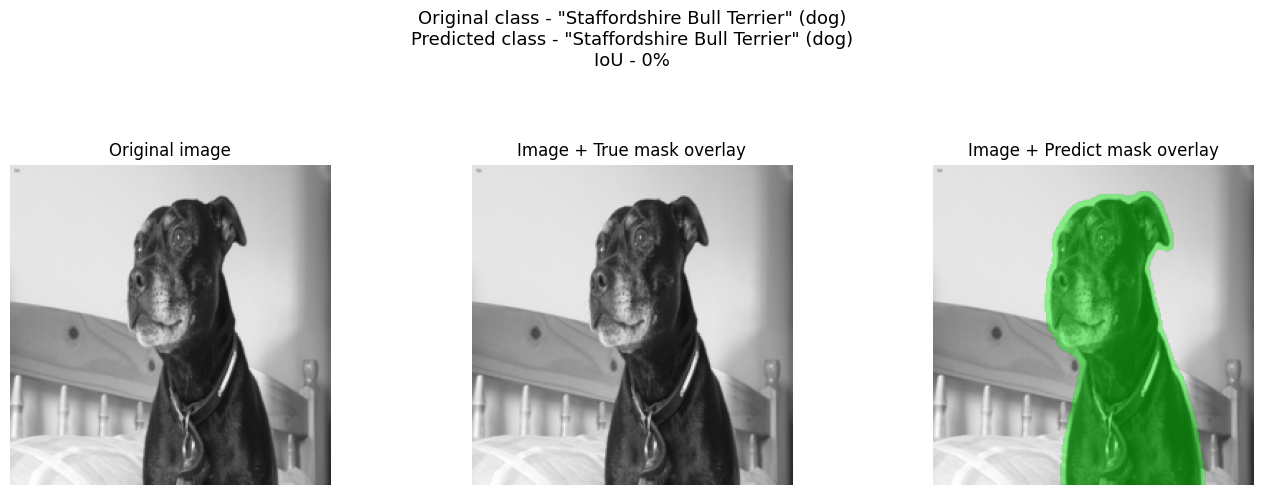

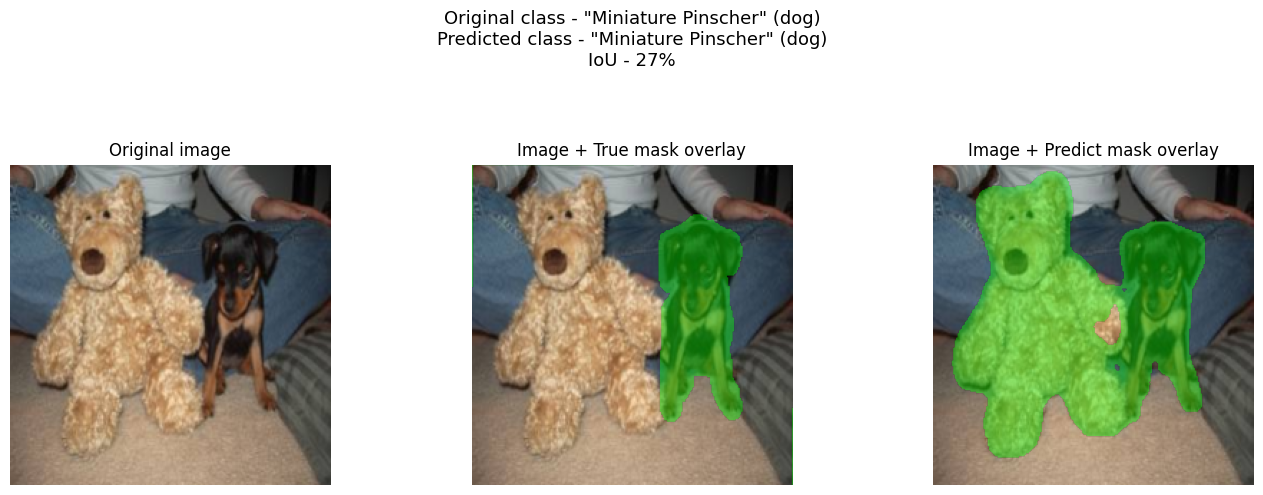

--- 3 most confident misclassifications ---
97.0% confident that "American Pit Bull Terrier" was "Staffordshire Bull Terrier"


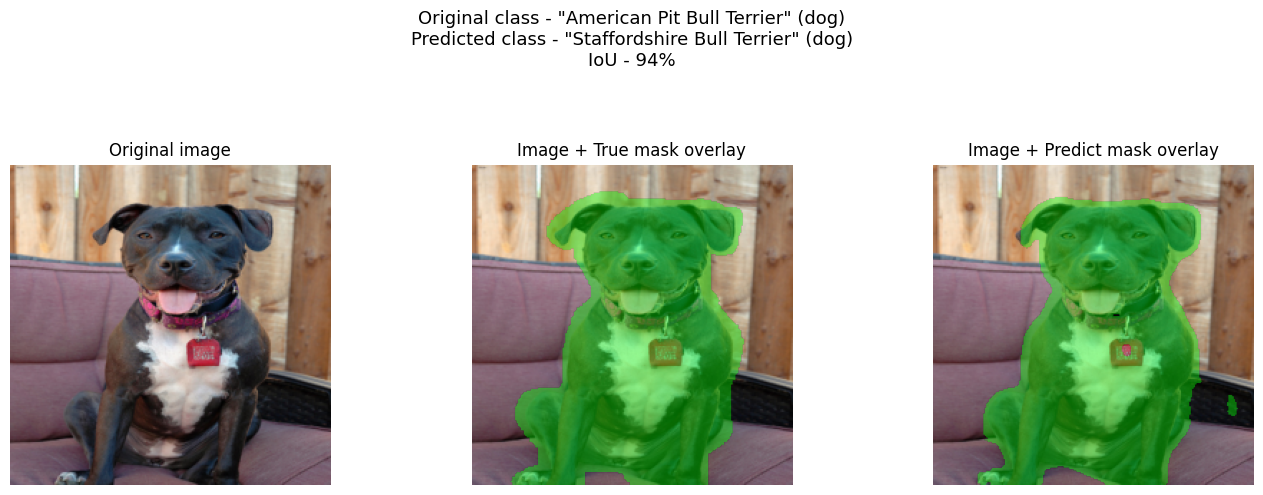

93.9% confident that "Staffordshire Bull Terrier" was "American Bulldog"


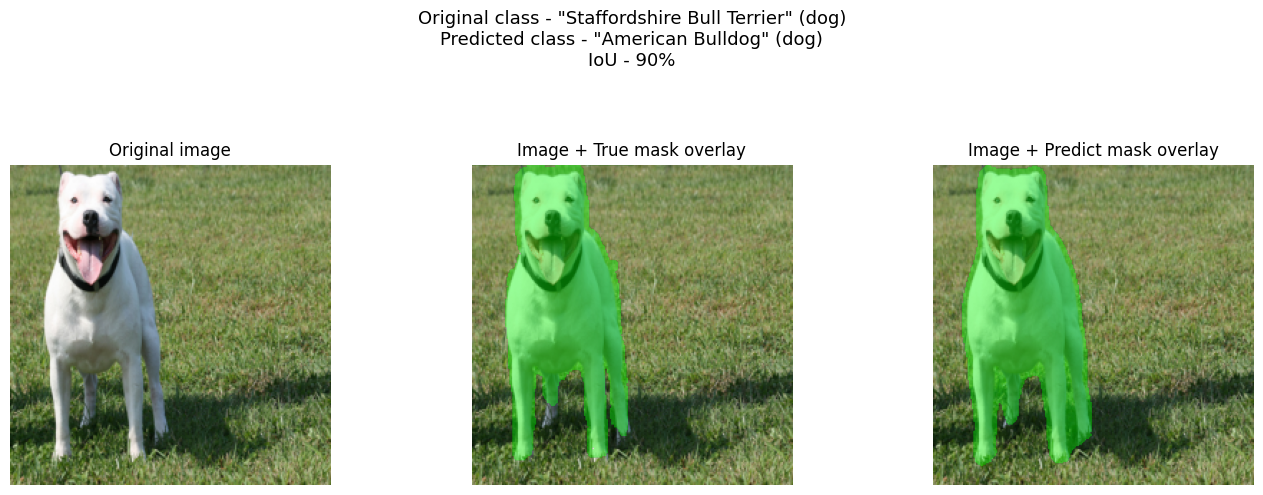

92.0% confident that "Ragdoll" was "Birman"


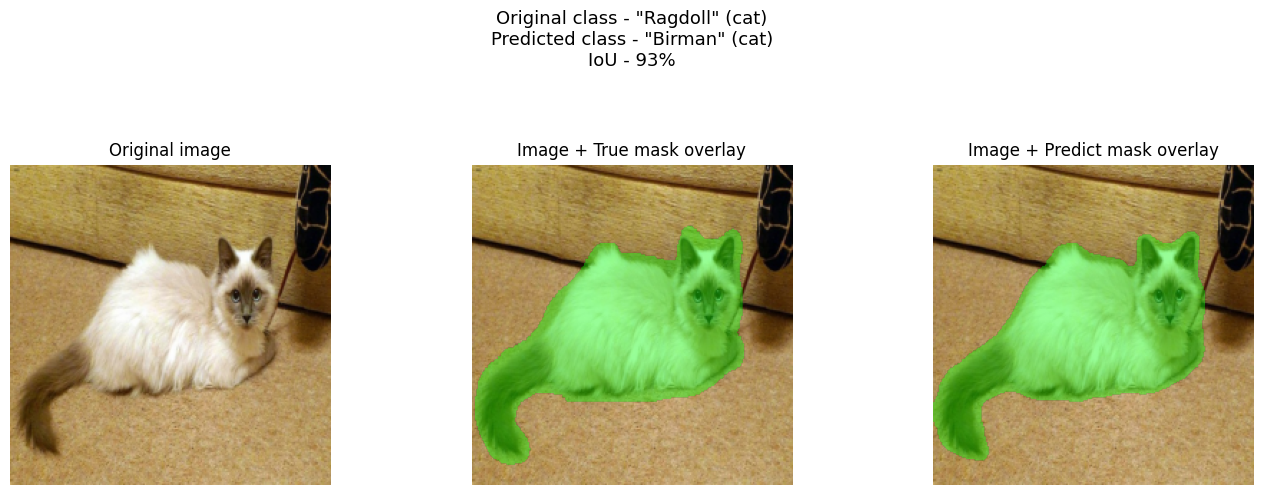

In [11]:
@torch.no_grad()
def worst_cases(model, ids, k=3, thr=None):
    thr = best_thr if thr is None else thr
    model.eval()
    sub = Subset(plain_ds, list(ids))
    ld = DataLoader(sub, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    ious, wrong, pos = [], [], 0
    for im, mk, lb in ld:
        im, mk, lb = im.to(device), mk.to(device), lb.to(device)
        with amp_ctx(USE_AMP):
            sl, cl = model(im)
        pred = (torch.sigmoid(sl.float()) > thr).long().squeeze(1)
        true = mk.long().squeeze(1)
        i = ((pred == 1) & (true == 1)).sum((1, 2)).float()
        u = ((pred == 1) | (true == 1)).sum((1, 2)).float()
        biou = (i / u.clamp(min=1)).cpu().numpy()
        conf, arg = torch.softmax(cl.float(), 1).max(1)
        for j in range(im.size(0)):
            ious.append((biou[j], pos + j))
            if arg[j] != lb[j]:
                wrong.append((conf[j].item(), pos + j, lb[j].item(), arg[j].item()))
        pos += im.size(0)

    print(f"--- {k} worst segmentations by Pet IoU ---")
    for v, j in sorted(ious)[:k]:
        show_prediction(model, sub, j, thr=thr)
    print(f"--- {k} most confident misclassifications ---")
    for c, j, t_, p_ in sorted(wrong, reverse=True)[:k]:
        print(f'{c*100:.1f}% confident that "{pretty(idx_to_breed[t_])}" was '
              f'"{pretty(idx_to_breed[p_])}"')
        show_prediction(model, sub, j, thr=thr)

worst_cases(model, test_idx, k=3)

## Which checkpoint to report

Each run saved two checkpoints: lowest total validation loss, and highest validation breed accuracy.
Usually different epochs, because the combined loss is a compromise between two tasks. Both criteria
are computed on validation, so choosing between them is model selection rather than peeking at test.

In [12]:
rows = []
for nm, (ck, ctor) in MODELS.items():
    m = ctor().to(device)
    for tag, suffix in [("best val loss", "bestloss"), ("best val ClsAcc", "bestcls")]:
        p = f"{ART_DIR}/{ck}_{suffix}.pth"
        if not os.path.exists(p): continue
        m.load_state_dict(torch.load(p, map_location=device), strict=True)
        r, _ = run_eval(m, test_loader, thr=0.5)
        rows.append({"run": nm, "checkpoint": tag, "Pet IoU": r["Pet IoU"],
                     "Cls Acc": r["Cls Acc"], "Top-5 Acc": r["Top-5 Acc"]})
    del m
    if device == "cuda": torch.cuda.empty_cache()

print(pd.DataFrame(rows).pivot(index="run", columns="checkpoint").round(4).to_string())
print("\nWhere the ClsAcc-selected column is higher, selecting on total validation loss alone was")
print("discarding the better classifier the same run had already produced.")

                                             Pet IoU                       Cls Acc                     Top-5 Acc              
checkpoint                           best val ClsAcc best val loss best val ClsAcc best val loss best val ClsAcc best val loss
run                                                                                                                           
1. Base U-Net                                 0.8548        0.8551          0.4265        0.4040          0.8332        0.8323
2. Attention U-Net                            0.8735        0.8735          0.1632        0.1632          0.5591        0.5591
3. Attention U-Net + aug                      0.8578        0.8613          0.0559        0.0640          0.2804        0.3066
4. ResNet34 random + aug                      0.8701        0.8697          0.3760        0.3715          0.8142        0.8142
5. ResNet34 ImageNet + aug                    0.9252        0.9249          0.9152        0.9098          0.988

# 7. Inference on an external image

No external image set. Demonstrating on a held-out test image instead.

True breed - Bengal



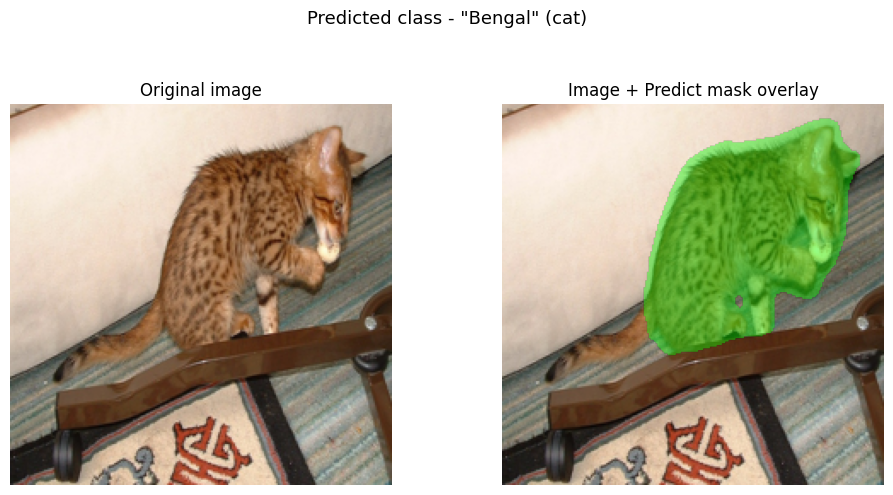

Top predictions -
  Bengal                            85.0%
  Wheaten Terrier                    0.9%
  Havanese                           0.9%


In [13]:
@torch.no_grad()
def predict_image(model, path, thr=None, topk=3):
    thr = best_thr if thr is None else thr
    model.eval()
    pil = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    image = TF.normalize(TF.to_tensor(pil), IMAGENET_MEAN, IMAGENET_STD)
    seg_logits, cls_logits = model(image.unsqueeze(0).to(device))
    pred_mask = (torch.sigmoid(seg_logits.float()) > thr).long().squeeze().cpu().numpy()
    prob = torch.softmax(cls_logits.float(), 1).squeeze(0)
    conf, ids = prob.topk(min(topk, NUM_CLASSES))
    top = [(idx_to_breed[i.item()], c.item()) for c, i in zip(conf, ids)]
    pb = top[0][0]

    img_np = denorm(image)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f'Predicted class - "{pretty(pb)}" ({species(pb)})', fontsize=13)
    axes[0].imshow(img_np); axes[0].set_title("Original image")
    axes[1].imshow(img_np); axes[1].imshow(overlay(pred_mask))
    axes[1].set_title("Image + Predict mask overlay")
    for a in axes: a.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.90]); plt.show(); plt.close(fig)
    print("Top predictions -")
    for b, c in top:
        print(f"  {pretty(b):<32} {c*100:5.1f}%")
    return top


EXTERNAL = ""      # e.g. "/kaggle/input/viva-images/dog.jpg"

if EXTERNAL and os.path.exists(EXTERNAL):
    predict_image(model, EXTERNAL)
else:
    print("No external image set. Demonstrating on a held-out test image instead.\n")
    s = samples[int(test_idx[0])]
    print(f"True breed - {pretty(s['breed'])}\n")
    predict_image(model, s["image"])

# 8. Saving config.json

In [14]:
abl_full = pd.read_csv(f"{ART_DIR}/ablation.csv", index_col=0)

config = {
    "breeds": breeds, "num_classes": NUM_CLASSES, "img_size": IMG_SIZE,
    "seed": SEED, "batch_size": BATCH_SIZE, "base_ch": BASE_CH,
    "imagenet_mean": IMAGENET_MEAN, "imagenet_std": IMAGENET_STD,
    "backbones": BACKBONES,
    "best_run": BEST_NAME, "best_ckpt": BEST_CKPT, "best_threshold": best_thr,
    "best_class": type(model).__name__,
    "best_backbone": getattr(model, "backbone_name", None),
    "split_sizes": {"train": len(tr_idx), "val": len(val_idx), "test": len(test_idx)},
    "test_stems": [os.path.basename(samples[int(i)]["image"])[:-4] for i in test_idx],
    "val_stems":  [os.path.basename(samples[int(i)]["image"])[:-4] for i in val_idx],
    "test_metrics": {k: float(v) for k, v in best_res.items()},
    "all_runs": {i: {k: float(v) for k, v in r.items() if k in METRIC_COLS}
                 for i, r in abl_full.iterrows()},
    "quick_test": False,
}
with open(f"{OUT_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"Wrote {OUT_DIR}/config.json ({os.path.getsize(f'{OUT_DIR}/config.json')/1024:.1f} kB)\n")
print(f"Best run   - {BEST_NAME}")
print(f"Checkpoint - {BEST_CKPT}_bestloss.pth")
print(f"Threshold  - {best_thr}")
print(f"Test       - Pet IoU {best_res['Pet IoU']:.4f} | mIoU {best_res['mIoU']:.4f} "
      f"| Cls Acc {best_res['Cls Acc']:.4f} | Top-5 {best_res['Top-5 Acc']:.4f}")

Wrote /kaggle/working/config.json (54.3 kB)

Best run   - 7. efficientnet_b0 ImageNet + aug
Checkpoint - bb_efficientnet_b0_bestloss.pth
Threshold  - 0.5
Test       - Pet IoU 0.9239 | mIoU 0.9344 | Cls Acc 0.9243 | Top-5 0.9901


# 9. Summary

In [15]:
print("All runs, test set\n")
print(abl_full.round(4).to_string())
print(f"\nBest by validation breed accuracy - {BEST_NAME}")
print(f"  Pet IoU {best_res['Pet IoU']:.4f}  (mIoU {best_res['mIoU']:.4f})")
print(f"  Breed   {best_res['Cls Acc']:.4f}  (top-5 {best_res['Top-5 Acc']:.4f})")
print(f"  Species {best_res['Species Acc']:.4f}")
print(f"\nTransfer learning effect, architecture held fixed:")
if "4. ResNet34 random + aug" in abl_full.index and "5. ResNet34 ImageNet + aug" in abl_full.index:
    a = float(abl_full.loc["4. ResNet34 random + aug", "Cls Acc"])
    b = float(abl_full.loc["5. ResNet34 ImageNet + aug", "Cls Acc"])
    print(f"  run 4 (random init) {a:.4f} -> run 5 (ImageNet init) {b:.4f}   {b-a:+.4f}")

All runs, test set

                                      Pixel Acc  Pet IoU    mIoU  Pet Dice   mDice  Cls Acc  Top-5 Acc  Species Acc  Precision  Recall      F1  train-val gap  min/epoch
1. Base U-Net                            0.9348   0.8551  0.8745    0.9219  0.9329   0.4040     0.8323       0.8927     0.3816  0.4037  0.3677         0.1524       2.06
2. Attention U-Net                       0.9437   0.8735  0.8907    0.9325  0.9421   0.1632     0.5591       0.7556     0.1092  0.1631  0.0993         0.0249       2.29
3. Attention U-Net + aug                 0.9388   0.8613  0.8813    0.9255  0.9368   0.0640     0.3066       0.7142     0.0143  0.0640  0.0189         0.0023       2.28
4. ResNet34 random + aug                 0.9421   0.8697  0.8876    0.9303  0.9404   0.3715     0.8142       0.9188     0.3541  0.3712  0.3314         0.0621       0.81
5. ResNet34 ImageNet + aug               0.9675   0.9249  0.9353    0.9610  0.9666   0.9098     0.9892       0.9928     0.9169  0.9097 

**new image check**

In [16]:
@torch.no_grad()
def predict_image(model, path, thr=None, topk=3):
thr = best_thr if thr is None else thr
model.eval()
pil = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
image = TF.normalize(TF.to_tensor(pil), IMAGENET_MEAN, IMAGENET_STD)

seg_logits, cls_logits = model(image.unsqueeze(0).to(device))
pred_mask = (torch.sigmoid(seg_logits.float()) > thr).long().squeeze().cpu().numpy()

prob = torch.softmax(cls_logits.float(), 1).squeeze(0)
conf, ids = prob.topk(min(topk, NUM_CLASSES))
top = [(idx_to_breed[i.item()], c.item()) for c, i in zip(conf, ids)]
pb = top[0][0]

img_np = denorm(image)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(f'Predicted class - "{pretty(pb)}" ({species(pb)})', fontsize=13)
axes[0].imshow(img_np); axes[0].set_title("Original image")
axes[1].imshow(img_np); axes[1].imshow(overlay(pred_mask))
axes[1].set_title("Image + Predict mask overlay")
for a in axes: a.axis("off")
plt.tight_layout(rect=[0, 0, 1, 0.90]); plt.show(); plt.close(fig)

print("Top predictions -")
for b, c in top:
print(f" {pretty(b):<32} {c*100:5.1f}%")
return top


EXTERNAL = "" # paste the image path here at the demo

if EXTERNAL and os.path.exists(EXTERNAL):
predict_image(model, EXTERNAL)
else:
print("No external image set. Demonstrating on a held-out test image instead.\n")
s = samples[int(test_idx[0])]
print(f"True breed - {pretty(s['breed'])}\n")
predict_image(model, s["image"])



IndentationError: expected an indented block after function definition on line 2 (645281605.py, line 3)